### Active Recognition for any dataset

Components required:
- Validation and test dataloaders
- Corresponding prediction model
- Corresponding fusion method

In [1]:
# import libraries
import os
import glob
import re
import yaml
import omegaconf
from tqdm import tqdm

import torch
import numpy as np
import pandas as pd

from scipy.io import loadmat
from skimage.transform import resize
from scipy.special import softmax
from sklearn.metrics import f1_score, confusion_matrix, balanced_accuracy_score, accuracy_score, classification_report
import matplotlib.pyplot as plt

# import local files
from main_multi_round import agent_builder, datamodule_builder
from evidential import DS_Combin, discounting_fit
from active_recog_helpers import diverse_permutation
from platt_scaling import platt_scaling_fit

/opt/conda/lib/python3.10/site-packages/torchvision/transforms/_functional_video.py:6: UserWarning: The 'torchvision.transforms._functional_video' module is deprecated since 0.12 and will be removed in the future. Please use the 'torchvision.transforms.functional' module instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/transforms/_transforms_video.py:22: UserWarning: The 'torchvision.transforms._transforms_video' module is deprecated since 0.12 and will be removed in the future. Please use the 'torchvision.transforms' module instead.
  warnings.warn(


In [2]:
# specify experimental settings
experiment_folder = '../logs/as_ce_logit_mmfix/round1'

In [3]:
# fetch configs from the experiment
cfg = omegaconf.OmegaConf.load(os.path.join(experiment_folder, 'hydra_config.yaml'))
cfg.data.batch_size = 1
ckpt_path = glob.glob(experiment_folder + '/**.ckpt')[0]

recognition_module = agent_builder(cfg.model.agent_name, cfg.model.init_args, save_dir=None)
recognition_module.load_only_weights(ckpt_path)

dm = datamodule_builder(cfg.dataset, cfg.data)
dm.setup("fit")
val_loader = dm.val_dataloader()
test_loader = dm.test_dataloader()
loss_type = cfg.model.init_args.loss

Model backbone initialized r2plus1d_18
Model state_dict loaded from ../logs/as_ce_logit_mmfix/round1/epoch=16-val_f1_epoch=0.82.ckpt
New dataset instantiated: split=train, mode=train
New dataset instantiated: split=val, mode=val
New dataset instantiated: split=test, mode=test
New dataset instantiated: split=val, mode=test


In [4]:
# configure GPU
device = 1
recognition_module.to(device).eval()
print(recognition_module.device)

cuda:1


In [5]:
# complete validation and test runs and store information
def common_batch(batch):
    with torch.no_grad():
        x = batch["x"].to(recognition_module.device)
        outs = recognition_module.forward(x)
        z = outs['z'].cpu()
        pred = outs['logits'].cpu()
    return {'z':z, 'pred':pred, 'y':batch['y'].item(), 'view':batch['view'].item(), 'uid':batch['uid'], 'study_id':batch['study_id']}
    
store_keys = ['z', 'pred', 'y', 'view', 'uid', 'study_id']
val_log, test_log = {}, {}
for k in store_keys:
    val_log[k] = []
    test_log[k] = []
    
for batch in tqdm(val_loader):
    out_dict = common_batch(batch)
    for k in store_keys:
        val_log[k].append(out_dict[k])

for batch in tqdm(test_loader):
    out_dict = common_batch(batch)
    for k in store_keys:
        test_log[k].append(out_dict[k])

100%|██████████████████████████████████████████████████████████████████████████| 1013/1013 [01:48<00:00,  9.31it/s]


In [6]:
def get_calibration_data(sm, y):
    # sm is N, C softmax output
    # compute the accuracy of each confidence decile
    confidences = np.max(sm, axis=1)
    preds = np.argmax(sm, axis=1)
    #print(confidences)
    confidence_hist, bin_edges = np.histogram(confidences, bins=np.arange(11)/10)
    #print(confidence_hist)
    #print(bin_edges)
    bin_association = np.digitize(confidences, bins=bin_edges)
    #print(np.unique(bin_association))
    calibration_x = []
    calibration_y = []
    ECE = 0
    for i in range(10):
        subset = bin_association == (i+1)
        if confidence_hist[i] > 0: # and i > 2:
            acc = accuracy_score(y[subset], preds[subset])
            
            calibration_x.append(i/10 + 0.05)
            calibration_y.append(acc)
            #print(np.mean(confidences[subset]))
            # calculate ECE
            ECE += confidence_hist[i] * np.abs(acc - np.mean(confidences[subset]))
    ECE = ECE / len(y)
    
    return calibration_x, calibration_y, ECE

def plot_calibration(x_arr, y_arr, names):
    plt.figure(figsize=(7,6))
    legend_names = []
    for i in range(len(x_arr)):
        if i in [0, 1, 2, 3, 4, 6]:
            print(x_arr[i])
            print(y_arr[i])
            plt.plot(x_arr[i], y_arr[i], marker='o')
            legend_names.append(names[i])
    plt.plot(np.arange(10)/10 + 0.05, np.arange(10)/10 + 0.05, marker='^', linestyle='dotted', color='black')
    plt.legend(legend_names + ['ideal'])
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title('Calibration of AS predictions (instance level) in deciles')
    plt.show()

In [7]:
# convert information into arrays
for k in ['pred', 'z']:
    val_log[k] = torch.stack(val_log[k]).squeeze()
    test_log[k] = torch.stack(test_log[k]).squeeze()

for k in ['y', 'view', 'uid']:
    val_log[k] = np.array(val_log[k]).squeeze()
    test_log[k] = np.array(test_log[k]).squeeze()

for k in ['study_id']:
    val_log[k] = torch.stack(val_log[k]).squeeze().numpy()
    test_log[k] = torch.stack(test_log[k]).squeeze().numpy()
    

In [8]:
#perform temperature tuning on the validation set
if loss_type == 'ce':
    temperature = platt_scaling_fit(logits=val_log['pred'], y=val_log['y'], num_iters=5000, mode="temp")
    test_log['pred'] = test_log['pred'] * temperature
    print(f"Temp = {temperature}")
elif loss_type == 'evidential':
    discounting = discounting_fit(evidence=val_log['pred'], y=val_log['y'], num_iters=1000)
    test_log['pred'] = test_log['pred'] * discounting
    print(f"Discount factor = {discounting}")

Temp = [1.0333072]


[0.35, 0.45, 0.55, 0.65, 0.75, 0.8500000000000001, 0.9500000000000001]
[0.3333333333333333, 0.3076923076923077, 0.5119047619047619, 0.594059405940594, 0.67, 0.8478260869565217, 0.9646365422396856]
[0.35, 0.45, 0.55, 0.65, 0.75, 0.8500000000000001, 0.9500000000000001]
[0.5, 0.3157894736842105, 0.5340909090909091, 0.5176470588235295, 0.7424242424242424, 0.8106796116504854, 0.9584199584199584]


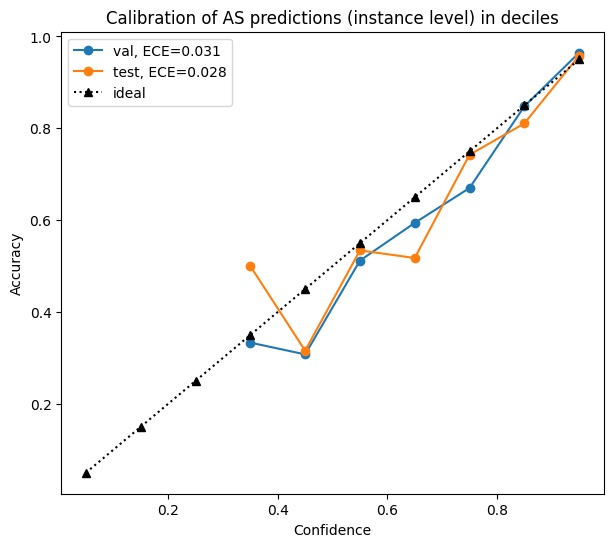

In [9]:
valx, valy, valECE = get_calibration_data(softmax(val_log['pred'].numpy(), axis=1), val_log['y'])
testx, testy, testECE = get_calibration_data(softmax(test_log['pred'].numpy(), axis=1), test_log['y'])
names = ["{}, ECE={:.3f}".format('val', valECE), "{}, ECE={:.3f}".format('test', testECE)]
plot_calibration([valx, testx], [valy, testy], names)

In [10]:
# finds similarity matrix between tensors and suggests sampling to improve diversity, NxD -> Nx1
def tensor_mutual_similarity(z_tensor):
    sim_matrix = torch.nn.functional.cosine_similarity(z_tensor.unsqueeze(0), z_tensor.unsqueeze(1), dim=2)
    sim_matrix = sim_matrix - sim_matrix.min()
    diversity_index = 1 / sim_matrix.sum(dim=1, keepdim=True)
    normalized_div_index = diversity_index / diversity_index.sum()
    return normalized_div_index

# intermediate fusion via averaging with tensor, NxD->1xC
def intermediate_fusion(z_tensor):
    avg_z = z_tensor.mean(dim=0, keepdim=True)
    avg_z_gpu = avg_z.to(recognition_module.device)
    with torch.no_grad():
        pred = recognition_module.decoder(avg_z_gpu)
    return pred.cpu()

# fusion via DST, NxC->1xC
def dst_fusion(pred_tensor, z_tensor=None):
    evidence = torch.nn.functional.relu(pred_tensor)
    alpha = evidence + 1
    if alpha.shape[0] == 1:
        return alpha

    # if z_tensor is not None and z_tensor.shape[0] >= 3:
    #     normalized_div_index = tensor_mutual_similarity(z_tensor)
    #     alpha = evidence * normalized_div_index * evidence.shape[0] + 1
        
    alpha_list = []
    for i in range(alpha.shape[0]):
        alpha_list.append(alpha[i:i+1])
    return DS_Combin(alpha_list)

# fusion by exponential moving average of class logits, with the latest logit being most highly weighted, NxC->1xC
def ema_logit(pred_tensor, alpha=0.7):
    N, D = pred_tensor.shape
    if N > 1:
        exponent = np.linspace(N-1, 0, N)[:, np.newaxis]
        scaling_factors = alpha ** exponent
        #scaling_factors = scaling_factors# / np.sum(scaling_factors)
        #print(scaling_factors)
        combined_pred = pred_tensor * scaling_factors
        return combined_pred.sum(dim=0, keepdim=True)
    else:
        return pred_tensor.sum(dim=0, keepdim=True)

# fusion by summing class logits, NxC->1xC
def sum_logit(pred_tensor):
    return pred_tensor.sum(dim=0, keepdim=True)

# fusion by averaging class logits, NxC->1xC
def avg_logit(pred_tensor, z_tensor=None):
    # opinion weighting based on diversity
    if z_tensor is not None and z_tensor.shape[0] >= 3:
        normalized_div_index = tensor_mutual_similarity(z_tensor)
        combined_pred = pred_tensor * normalized_div_index
        return combined_pred.sum(dim=0, keepdim=True)
    else:
        return pred_tensor.sum(dim=0, keepdim=True)
        #return pred_tensor.mean(dim=0, keepdim=True)

def fuse_wrapper(z_tensor, pred_tensor, choice='inter'):
    if choice == 'inter':
        return intermediate_fusion(z_tensor)
    elif choice == 'evidential':
        return dst_fusion(pred_tensor)
    elif choice == 'logit':
        return avg_logit(pred_tensor, z_tensor)
    elif choice == 'logit_sum':
        return sum_logit(pred_tensor)
    elif choice == 'logit_ema':
        return ema_logit(pred_tensor)


In [11]:
def score_wrapper(pred, score_method, loss_type): # C -> scalar
    if loss_type == 'ce':
        confidence = softmax(pred)
    elif loss_type == 'evidential':
        alpha = pred.clip(min=1)
        confidence = alpha / np.sum(alpha)
    else:
        raise NotImplementedError
        
    if score_method == 'confidence':
        return np.max(confidence)
    elif score_method == 'evidential' and loss_type == 'evidential':
        return np.max(alpha)
    else:
        raise NotImplementedError

In [12]:
# run active recognition with a set threshold
def active_w_threshold(z, pred, view, fusion_method='logit', score_method='confidence', threshold=0.0, max_vids=4):
    # z and pred are length N, where N is the number of cases to fuse together
    N, D = pred.shape
    self_stop = False
    N_queries = 0
    # randomly sample indices without replacement
    rand_order = diverse_permutation(view)
    for i in range(min(N,max_vids)):
        N_queries = N_queries + 1
        current_group = rand_order[:i+1]
        combined_prediction = fuse_wrapper(z[current_group], pred[current_group], fusion_method).squeeze().numpy()
        score = score_wrapper(combined_prediction, score_method, loss_type)
        if score >= threshold:
            return combined_prediction, N_queries, True
    return combined_prediction, N_queries, self_stop

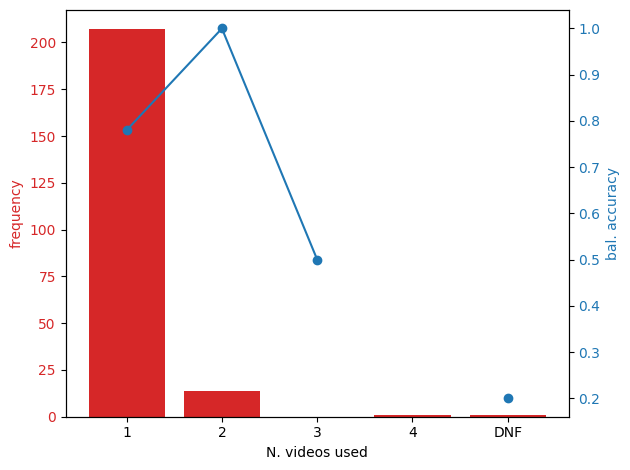

In [13]:
def plot_bar_by_line(bar_data, line_data, title=None):
    fig, ax1 = plt.subplots()
    x = np.arange(len(bar_data))
    x_names = [str(i+1) for i in x]
    x_names[-1] = 'DNF'
    
    color = 'tab:red'
    ax1.set_xlabel('N. videos used')
    ax1.set_ylabel('frequency', color=color)
    ax1.bar(x_names, bar_data, color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
    
    color = 'tab:blue'
    ax2.set_ylabel('bal. accuracy', color=color)  # we already handled the x-label with ax1
    ax2.plot(x, line_data, 'o-', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    fig.suptitle(title)
    plt.show()

plot_bar_by_line([207, 14, np.nan, 1, 1], [0.78, 1.0, 0.5, np.nan, 0.2])

In [14]:
# iterate over known thresholds and measure performance at each
track_log = val_log

baccs, ts, mnq, mss = [], [], [], []
for t in np.linspace(0.4, 1, 10):
    studies = {'id':[], 'y':[], 'pred':[], 'len':[], 'nq':[], 'ss':[]}
    for s in tqdm(np.unique(track_log['study_id'])):
        mask = track_log['study_id'] == s
        if np.sum(mask) < 4:
            continue
        if loss_type == 'ce':
            pred, nq, ss = active_w_threshold(track_log['z'][mask], track_log['pred'][mask], track_log['view'][mask], 'logit', 'confidence', t, 4)
        if loss_type == 'evidential':
            pred, nq, ss = active_w_threshold(track_log['z'][mask], track_log['pred'][mask], track_log['view'][mask], 'evidential', 'confidence', t, 4)
        studies['id'].append(s)
        studies['y'].append(track_log['y'][mask][0])
        studies['pred'].append(pred)
        studies['len'].append(np.sum(mask))
        studies['nq'].append(nq)
        studies['ss'].append(ss)

    finished_mask = np.array(studies['ss']) == True
    n_j, acc_j = [], []
    for j in range(np.max(studies['nq'])):
        j_videos_mask = np.array(studies['nq']) == (j+1)
        subset_mask = np.logical_and(j_videos_mask, finished_mask)
        #subset_mask = np.array(studies['len']) == (j+1)
        n_j.append(np.sum(subset_mask))
        acc_j.append(balanced_accuracy_score(np.array(studies['y'])[subset_mask], np.argmax(np.array(studies['pred'])[subset_mask], axis=1)))
        #print(confusion_matrix(np.array(studies['y'])[subset_mask], np.argmax(np.array(studies['pred'])[subset_mask], axis=1), labels=[0,1,2]))
    dnf_mask = ~finished_mask
    n_dnf = np.sum(dnf_mask)
    acc_dnf = balanced_accuracy_score(np.array(studies['y'])[dnf_mask], np.argmax(np.array(studies['pred'])[dnf_mask], axis=1))

    n_j.append(n_dnf)
    acc_j.append(acc_dnf)
    title = f"Threshold = {t:.2f}, N_DNF = {n_dnf}"
    
    #plot_bar_by_line(n_j, acc_j, title)
    print(acc_j)

    ts.append(t)
    mnq.append(np.mean(np.array(studies['nq'])))
    mss.append(np.mean(studies['ss']))
    #baccs.append(balanced_accuracy_score(np.array(studies['y'])[finished_mask], np.argmax(np.array(studies['pred'])[finished_mask], axis=1)))
    baccs.append(accuracy_score(np.array(studies['y']), np.argmax(np.array(studies['pred']), axis=1)))

df = pd.DataFrame.from_dict({'threshold':ts, 'mean_images':mnq, 'bacc':baccs, 'finishrate':mss})
#df.to_csv('ev_no_rt.csv')
df

100%|██████████████████████████████████████████████████████████████████████████| 283/283 [00:00<00:00, 3619.78it/s]
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[0.8226292226292227, 1.0, nan]


100%|██████████████████████████████████████████████████████████████████████████| 283/283 [00:00<00:00, 3990.45it/s]
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[0.8368530020703934, 1.0, nan]


100%|██████████████████████████████████████████████████████████████████████████| 283/283 [00:00<00:00, 3012.07it/s]
/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

[1.0, 0.9476923076923077, nan, nan, 0.7658730158730158]


100%|██████████████████████████████████████████████████████████████████████████| 283/283 [00:00<00:00, 1413.47it/s]

[nan, nan, nan, nan, 0.8631469979296066]



/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/s

,threshold,mean_images,bacc,finishrate
0,0.400000,1.005952,0.815476,1.000000
1,0.466667,1.011905,0.833333,1.000000
2,0.533333,1.059524,0.809524,1.000000
3,0.600000,1.178571,0.833333,0.988095
4,0.666667,1.130952,0.839286,1.000000
5,0.733333,1.333333,0.863095,0.940476
6,0.800000,1.613095,0.857143,0.875000
7,0.866667,1.839286,0.857143,0.803571
8,0.933333,2.261905,0.875000,0.690476
9,1.000000,4.000000,0.863095,0.000000


In [15]:
studies = {'id':[], 'y':[], 'pred':[], 'nq':[], 'ss':[]}
for s in tqdm(np.unique(test_log['study_id'])):
    mask = test_log['study_id'] == s
    pred, nq, ss = active_w_threshold(test_log['z'][mask], test_log['pred'][mask], test_log['view'][mask], 'logit', 'confidence', 0.99)
    print(test_log['pred'][mask])
    print(pred)
    print(nq)
    print(ss)
    assert False
    studies['id'].append(s)
    studies['y'].append(test_log['y'][mask][0])
    studies['pred'].append(pred)
    studies['nq'].append(nq)
    studies['ss'].append(ss)

  0%|                                                                                      | 0/256 [00:00<?, ?it/s]


tensor([[-2.3953, -0.3426,  2.5985],
        [-2.4917, -0.5276,  2.8963],
        [-2.2354,  1.1645,  1.0955]])
[-2.3479903  0.3054688  1.983825 ]
3
False


AssertionError: 

In [ ]:
studies['nq']